# FULL — Utah FORGE 56-32 Geothermal Drilling Sensor Clustering with K-Means (Kaggle, English)

**Title (IEEE):** Impact of Feature Scaling and Temporal Window Aggregation on Multivariate Geothermal Drilling Sensor Clustering Using K-Means

**One-notebook final version.** Merges `01_eda` + `02_scaling` + `03_window` + `04_clustering` into a single Kaggle run (~20–30 min on CPU, RAM-safe).

## Step-by-step map (use this table in paper §II as pipeline figure)

| Step | Goal | Input → Output | Paper section |
|---|---|---|---|
| 0. Setup | Resolve Kaggle input path, set seed=42 | Dataset `utah-forge-56-32-1sec` → `df` | Reproducibility note |
| 1.0 Taxonomy | Formal sensor taxonomy, units, groups, physical roles & selection | Sensor list → `table0_sensor_taxonomy.csv` | §II-A Data Understanding |
| 1. EDA | Descriptive stats, scale audit, correlation, boxplot, `-999.25` audit | 80k sample → `table1_descriptive.csv`, `fig1_correlation.png`, `fig2_boxplots.png` | §II-A Data Understanding |
| 2. Scaling | Prove Euclidean bias; compare Standard vs Robust | 20k sample, k=4 demo → `table2_scaler_compare.csv`, `fig3_scaling_hist.png` | §II-B Preprocessing |
| 3. Windowing | Keep temporal dependency (Keogh & Lin 2005: cluster features, not raw subsequences) | 30k rows → 60s/30s mean+std+delta (24-D) → `table3_temporal_compare.csv`, `fig4_temporal_trace.png` | §II-C Temporal Aggregation |
| 4. Clustering | Elbow k=2..8 × 4 scenarios, Silhouette + DBI, centroids → Coley (2019) regimes | 60k sample → `table4_elbow_metrics.csv`, `fig5_elbow_silhouette.png`, `table5_centroids.csv`, `fig6_pca_clusters.png` | §III Results |
| 5. Export | Download `/kaggle/output/` for IEEE tables/figures | All tables+figures | Appendix + repo link |

> **Kaggle setup:** New Notebook → Add Input → private dataset `utah-forge-56-32-1sec` (the 357 MB CSV). Runtime: CPU, no GPU needed. All captions/labels are English-ready.


#### Cell: Setup — imports, constants, input resolver
**What:** imports libraries, defines the 8-sensor list (`SENSOR_8`), sample sizes, `SEED=42`, and `resolve_input()` which finds the CSV inside `/kaggle/input` (recursive + fuzzy match) with a local `dataset/` fallback.
**Why:** one seed and one path rule keep every run reproducible on Kaggle and locally.
**Read this:** the printed `INPUT` path (must point to your CSV) and `OUTPUT` folder (`/kaggle/output` on Kaggle).


In [ ]:
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score

SENSOR_8 = ['Rate Of Penetration (ft_per_hr)','Weight on Bit (klbs)','Rotary RPM (RPM)','Standpipe Pressure (psi)','Rotary Torque (kft_lb)','Hook Load (klbs)','Total Pump Output (gal_per_min)','Differential Pressure (psi)']
CSV_NAME = '56-32 1sec data 27029986.csv'
SEED = 42
N_EDA, N_SCALE, N_WIN_SRC, N_FINAL = 80000, 20000, 30000, 60000

def resolve_input(csv=CSV_NAME):
    root = Path('/kaggle/input')
    if root.exists():
        hits = list(root.rglob(csv))
        if hits:
            return hits[0]
        for p in root.rglob('*.csv'):
            if '56-32' in p.name or '1sec' in p.name or '27029986' in p.name:
                return p
        csvs = [p for p in root.rglob('*.csv') if p.is_file()]
        if csvs:
            return max(csvs, key=lambda p: p.stat().st_size)
        pqs = [p for p in root.rglob('*.parquet') if p.is_file()]
        if pqs:
            return max(pqs, key=lambda p: p.stat().st_size)
    for c in [Path('dataset')/csv, Path('../dataset')/csv, Path.cwd()/'dataset'/csv]:
        if c.exists(): return c
    listing = [str(p) for p in sorted(root.rglob('*'))][:30] if root.exists() else ['</kaggle/input not found>']
    raise FileNotFoundError('Dataset CSV not found. /kaggle/input contains: ' + str(listing) + ' | Fix: right panel Add Input -> add your private dataset -> re-run.')

OUT = Path('/kaggle/output') if Path('/kaggle/output').exists() else Path('../figures')
OUT.mkdir(parents=True, exist_ok=True)
print('INPUT:', resolve_input())
print('OUTPUT:', OUT)

INPUT: /kaggle/input/datasets/faruqmahdison/utah-datmin/56-32 1sec data 27029986.csv
OUTPUT: ../figures


## Step 1 — EDA (Data Understanding)
**Why:** (a) quantify scale disparity (psi ~thousands vs torque ~tens → Euclidean bias), (b) confirm `Pason Gas`/`Gamma` are inactive (`-999.25`), (c) correlation + outliers for sensor selection justification (need ≥5 continuous numeric, unlabeled).

#### Cell: Load EDA sample
**What:** reads only the needed columns (`usecols`), downcasts to `float32`, takes a random 80k-row sample, and builds a `datetime` index from date + time columns.
**Why:** the full 2.5M-row file is too heavy for EDA; sampling + `float32` keeps RAM safe while staying representative.
**Read this:** printed shape and time range — confirms the sample loaded correctly.


In [ ]:
path = resolve_input()
usecols = ['YYYY/MM/DD','HH:MM:SS'] + SENSOR_8
eda = pd.read_csv(path, usecols=usecols, nrows=N_EDA*2, low_memory=True)
rng = np.random.RandomState(SEED)
if len(eda) > N_EDA:
    eda = eda.iloc[np.sort(rng.choice(len(eda), N_EDA, replace=False))].reset_index(drop=True)
for c in SENSOR_8: eda[c] = pd.to_numeric(eda[c], errors='coerce').astype('float32')
eda['datetime'] = pd.to_datetime(eda['YYYY/MM/DD']+' '+eda['HH:MM:SS'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
print(eda.shape, eda['datetime'].min(), '->', eda['datetime'].max())
display(eda.head(2))

(80000, 11) 2021-02-08 04:30:00 -> 2021-02-10 00:56:39


,YYYY/MM/DD,HH:MM:SS,Rate Of Penetration (ft_per_hr),Weight on Bit (klbs),Rotary RPM (RPM),Standpipe Pressure (psi),Rotary Torque (kft_lb),Hook Load (klbs),Differential Pressure (psi),Total Pump Output (gal_per_min),datetime
0,2021/02/08,04:30:00,0.0,0.0,0.03,0.0,0.005,56.799999,0.0,0.0,2021-02-08 04:30:00
1,2021/02/08,04:30:03,0.0,0.0,0.03,0.0,0.005,56.799999,0.0,0.0,2021-02-08 04:30:03


#### Cell: Sensor Taxonomy (Formal Drilling Sensor Specification) → `table0_sensor_taxonomy.csv`
**What:** defines the formal multi-dimensional taxonomy for all 10 logging-while-drilling (surface/LWD) sensors, detailing formal nomenclature, physical units, measurement groups (kinematic, mechanical, hydraulic, petrophysical), data types, physical interpretations, operational process roles, and selection status.
**Why:** establishes a rigorous domain-specific grounding (SPE/IADC drilling engineering standard) prior to data transformation, formally justifying why the 8 continuous drilling sensors (`SENSOR_8`) are retained while sentinel channels (`-999.25`) are excluded.
**Read this:** comprehensive taxonomy table categorizing the 8 modeled features + 2 audited sentinel sensors; exported to `table0_sensor_taxonomy.csv` and `tabel_taksonomi_sensor.xlsx`.

In [3]:
import pandas as pd

# Formal Sensor Taxonomy Definition (Utah FORGE 56-32 Geothermal Well)
sensor_taxonomy_dict = {
    "Rate Of Penetration (ft_per_hr)": {
        "Abbreviation": "ROP",
        "Full Name": "Rate of Penetration",
        "Unit": "ft/hr",
        "Measurement Group": "Drilling Performance (Kinematics)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The axial linear speed at which the drill bit penetrates and cuts the rock formation.",
        "Process Role": "Indicator of progress and rock-cutting efficiency; primary component of MSE evaluation.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Weight on Bit (klbs)": {
        "Abbreviation": "WOB",
        "Full Name": "Weight on Bit",
        "Unit": "klbs",
        "Measurement Group": "Mechanical (Axial Load)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The gravitational axial load applied directly onto the drill bit at the bottom of the well.",
        "Process Role": "Controls the depth of cut in the rock; main control parameter for penetration and bit wear.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Rotary RPM (RPM)": {
        "Abbreviation": "RPM",
        "Full Name": "Rotary Speed / Revolutions Per Minute",
        "Unit": "rpm",
        "Measurement Group": "Mechanical (Rotational Kinematics)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The rotational frequency of the drill string or rotary table / top drive per minute.",
        "Process Role": "Provides rotational energy for rock scraping and assists in efficient drilling cuttings circulation.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Standpipe Pressure (psi)": {
        "Abbreviation": "SPP",
        "Full Name": "Standpipe Pressure",
        "Unit": "psi",
        "Measurement Group": "Hydraulic (Fluid Circulation)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The hydraulic pressure of the drilling mud at the rig standpipe before entering the drill string.",
        "Process Role": "Reflects frictional pressure losses during circulation; indicator of pump stability and system integrity.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Rotary Torque (kft_lb)": {
        "Abbreviation": "Torque",
        "Full Name": "Rotary Torque",
        "Unit": "kft_lb",
        "Measurement Group": "Mechanical (Rotational Torque)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The rotational moment of force required to rotate the drill string against rock and borehole wall resistance.",
        "Process Role": "Indicates shear resistance of the rock; used to detect stick-slip vibrations, formation changes, and pipe stuck risks.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Hook Load (klbs)": {
        "Abbreviation": "HKLD",
        "Full Name": "Hook Load",
        "Unit": "klbs",
        "Measurement Group": "Mechanical (Axial Tensile Load)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The total downward pull force on the rig traveling block (total drill string weight corrected for buoyancy).",
        "Process Role": "The basis for calculating actual WOB; monitors axial friction (drag) and differentiates on/off-bottom regimes.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Total Pump Output (gal_per_min)": {
        "Abbreviation": "TPO / Flow Rate",
        "Full Name": "Total Pump Output (Mud Flow Rate)",
        "Unit": "gal_per_min",
        "Measurement Group": "Hydraulic (Volumetric Flow Rate)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The total volumetric flow rate of drilling mud circulated by the mud pumps.",
        "Process Role": "Hole cleaning (carrying cuttings out), cooling the drill bit, and transmitting downhole hydraulic power.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Differential Pressure (psi)": {
        "Abbreviation": "Diff Press / ΔP",
        "Full Name": "Differential Pressure",
        "Unit": "psi",
        "Measurement Group": "Hydraulic (Downhole Motor Load)",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The difference in hydraulic pressure between on-bottom drilling and off-bottom free circulation.",
        "Process Role": "Measures the hydraulic workload on the downhole motor (PDM); directly correlates with bit torque.",
        "Selection Status": "Primary Feature (Modeled)"
    },
    "Pason Gas (percent)": {
        "Abbreviation": "Gas",
        "Full Name": "Mud Gas Concentration (Pason Gas)",
        "Unit": "%",
        "Measurement Group": "Geochemical / Mud Logging",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The concentration of hydrocarbon gas fraction released from the formation into the circulating mud.",
        "Process Role": "Safety evaluation of formation fluids; excluded because ~100% of values are the sentinel -999.25.",
        "Selection Status": "Excluded (Sentinel ~100% -999.25)"
    },
    "Gamma (api)": {
        "Abbreviation": "GR",
        "Full Name": "Gamma Ray Log",
        "Unit": "api",
        "Measurement Group": "Petrophysical / MWD-LWD",
        "Data Type": "Continuous (Ratio)",
        "Physical Meaning": "The intensity of natural gamma radiation emitted from the formation (used for lithology determination).",
        "Process Role": "Discrimination of subsurface lithology; excluded because ~100% of values are the sentinel -999.25.",
        "Selection Status": "Excluded (Sentinel ~100% -999.25)"
    }
}

# Creating the sensor taxonomy DataFrame
taxonomy_rows = []
for col_name, info in sensor_taxonomy_dict.items():
    taxonomy_rows.append({"Sensor / Dataset Column": col_name, **info})

sensor_taxonomy = pd.DataFrame(taxonomy_rows)

# Display or print the sensor taxonomy table
try:
    display(sensor_taxonomy)
except NameError:
    print(sensor_taxonomy.to_string(index=False))


,Sensor / Dataset Column,Abbreviation,Full Name,Unit,Measurement Group,Data Type,Physical Meaning,Process Role,Selection Status
0,Rate Of Penetration (ft_per_hr),ROP,Rate of Penetration,ft/hr,Drilling Performance (Kinematics),Continuous (Ratio),The axial linear speed at which the drill bit ...,Indicator of progress and rock-cutting efficie...,Primary Feature (Modeled)
1,Weight on Bit (klbs),WOB,Weight on Bit,klbs,Mechanical (Axial Load),Continuous (Ratio),The gravitational axial load applied directly ...,Controls the depth of cut in the rock; main co...,Primary Feature (Modeled)
2,Rotary RPM (RPM),RPM,Rotary Speed / Revolutions Per Minute,rpm,Mechanical (Rotational Kinematics),Continuous (Ratio),The rotational frequency of the drill string o...,Provides rotational energy for rock scraping a...,Primary Feature (Modeled)
3,Standpipe Pressure (psi),SPP,Standpipe Pressure,psi,Hydraulic (Fluid Circulation),Continuous (Ratio),The hydraulic pressure of the drilling mud at ...,Reflects frictional pressure losses during cir...,Primary Feature (Modeled)
4,Rotary Torque (kft_lb),Torque,Rotary Torque,kft_lb,Mechanical (Rotational Torque),Continuous (Ratio),The rotational moment of force required to rot...,Indicates shear resistance of the rock; used t...,Primary Feature (Modeled)
5,Hook Load (klbs),HKLD,Hook Load,klbs,Mechanical (Axial Tensile Load),Continuous (Ratio),The total downward pull force on the rig trave...,The basis for calculating actual WOB; monitors...,Primary Feature (Modeled)
6,Total Pump Output (gal_per_min),TPO / Flow Rate,Total Pump Output (Mud Flow Rate),gal_per_min,Hydraulic (Volumetric Flow Rate),Continuous (Ratio),The total volumetric flow rate of drilling mud...,"Hole cleaning (carrying cuttings out), cooling...",Primary Feature (Modeled)
7,Differential Pressure (psi),Diff Press / ΔP,Differential Pressure,psi,Hydraulic (Downhole Motor Load),Continuous (Ratio),The difference in hydraulic pressure between o...,Measures the hydraulic workload on the downhol...,Primary Feature (Modeled)
8,Pason Gas (percent),Gas,Mud Gas Concentration (Pason Gas),%,Geochemical / Mud Logging,Continuous (Ratio),The concentration of hydrocarbon gas fraction ...,Safety evaluation of formation fluids; exclude...,Excluded (Sentinel ~100% -999.25)
9,Gamma (api),GR,Gamma Ray Log,api,Petrophysical / MWD-LWD,Continuous (Ratio),The intensity of natural gamma radiation emitt...,Discrimination of subsurface lithology; exclud...,Excluded (Sentinel ~100% -999.25)


#### Cell: Descriptive statistics → `table1_descriptive.csv`
**What:** computes mean, std, min/max, quartiles, skewness, and range per sensor and saves Table 1.
**Why:** quantifies the scale disparity (psi in thousands vs torque in tens) — the core problem statement for the paper.
**Read this:** compare the `std`/`range` of Standpipe Pressure against Rotary Torque and WOB; that gap is the Euclidean-bias evidence.


In [ ]:
desc = eda[SENSOR_8].replace(-999.25, np.nan).describe(percentiles=[.25,.5,.75]).T
desc['skew'] = eda[SENSOR_8].replace(-999.25, np.nan).skew(numeric_only=True)
desc['range'] = desc['max'] - desc['min']
display(desc.round(2))
desc.round(2).to_csv(OUT/'table1_descriptive.csv')
# Reading guide: compare std/range of Standpipe Pressure vs Rotary Torque — that gap IS the scale-disparity problem.

,count,mean,std,min,25%,50%,75%,max,skew,range
Rate Of Penetration (ft_per_hr),80000.0,59.62,233.41,0.00,0.00,0.00,0.00,10980.79,16.719999,10980.79
Weight on Bit (klbs),80000.0,1.74,5.76,0.00,0.00,0.00,0.00,81.30,4.090000,81.30
Rotary RPM (RPM),80000.0,11.60,24.06,0.00,0.03,0.03,0.03,113.79,1.760000,113.79
Standpipe Pressure (psi),80000.0,510.83,1081.55,0.00,0.00,0.00,86.05,5139.71,2.050000,5139.71
Rotary Torque (kft_lb),80000.0,1.14,3.00,0.00,0.00,0.00,0.00,31.88,3.540000,31.88
Hook Load (klbs),80000.0,62.50,18.93,31.80,55.00,55.20,57.80,151.30,2.080000,119.50
Total Pump Output (gal_per_min),80000.0,163.63,306.54,0.00,0.00,0.00,61.88,897.54,1.500000,897.54
Differential Pressure (psi),80000.0,-771.45,1516.39,-5138.83,-1325.41,-92.12,-92.12,5119.15,-2.050000,10257.98


#### Cell: Missing-code audit (`-999.25`)
**What:** checks the fraction of `-999.25` sentinel values in `Pason Gas` and `Gamma` on a 20k-row probe.
**Why:** `-999.25` means an inactive sensor, not a real measurement; both columns are ~100% sentinel so they must be dropped.
**Read this:** both ratios ≈ 1.0 → decision: DROP both, keep the 8-sensor set.


In [ ]:
chk = pd.read_csv(path, usecols=['Pason Gas (percent)','Gamma (api)'], nrows=20000)
print('Pason Gas == -999.25:', float((chk['Pason Gas (percent)']==-999.25).mean()))
print('Gamma == -999.25:', float((chk['Gamma (api)']==-999.25).mean()))
print('Decision: DROP both (inactive sensors). Keep the 8-sensor set.')

Pason Gas == -999.25: 1.0
Gamma == -999.25: 1.0
Decision: DROP both (inactive sensors). Keep the 8-sensor set.


#### Cell: Correlation + boxplots → `fig1`, `fig2`
**What:** draws the 8×8 correlation heatmap and one boxplot per sensor (clipped to 1st–99th percentile for readability).
**Why:** correlation reveals redundant/coupled sensors; boxplots reveal outliers before clustering.
**Read this:** strong off-diagonal correlations (pump ↔ pressure) and long boxplot whiskers = real drilling outliers to discuss, not delete blindly.


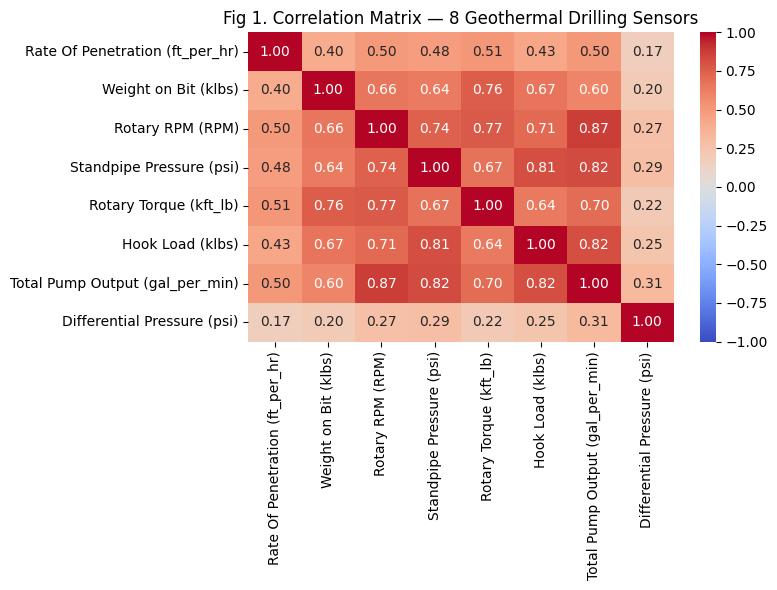

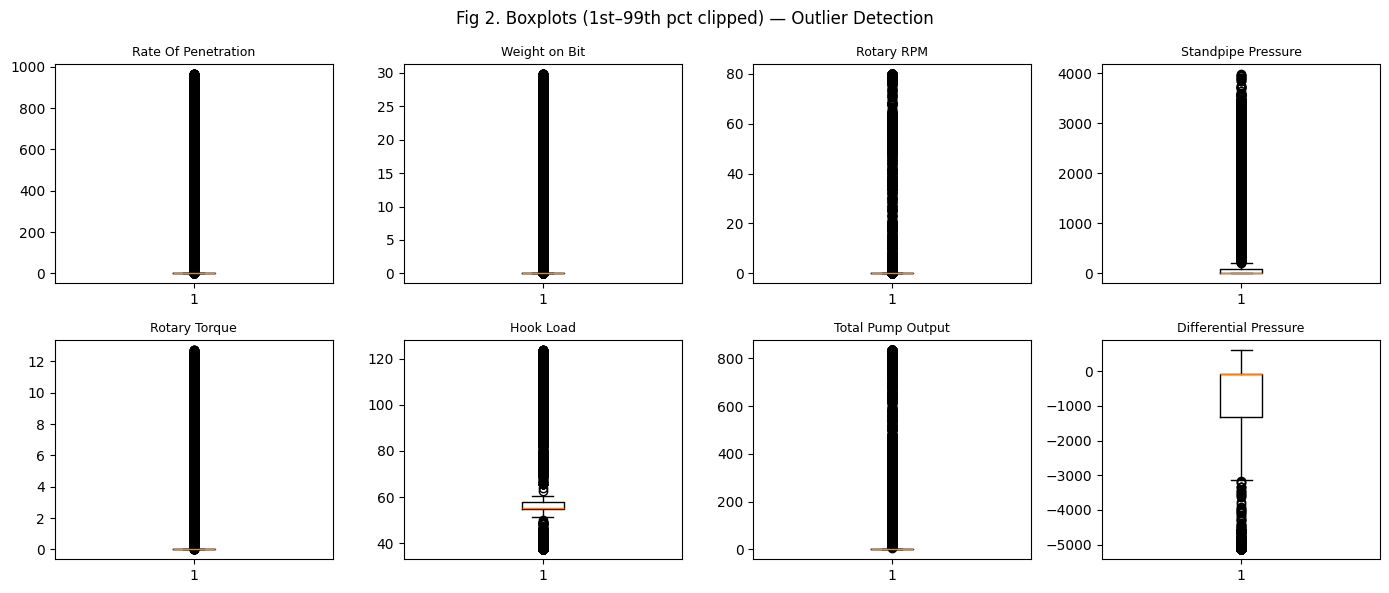

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(eda[SENSOR_8].replace(-999.25, np.nan).corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Fig 1. Correlation Matrix — 8 Geothermal Drilling Sensors')
plt.tight_layout(); plt.savefig(OUT/'fig1_correlation.png', dpi=150); plt.show()

fig, ax = plt.subplots(2,4, figsize=(14,6))
for a, c in zip(ax.ravel(), SENSOR_8):
    v = eda[c].replace(-999.25, np.nan).dropna().to_numpy()
    lo, hi = np.percentile(v,[1,99])
    a.boxplot(v[(v>=lo)&(v<=hi)], vert=True); a.set_title(c.split(' (')[0], fontsize=9)
plt.suptitle('Fig 2. Boxplots (1st–99th pct clipped) — Outlier Detection')
plt.tight_layout(); plt.savefig(OUT/'fig2_boxplots.png', dpi=150); plt.show()

## Step 2 — Scaling (StandardScaler vs RobustScaler)
**Why:** K-Means uses Euclidean distance. Without scaling, `Standpipe Pressure` (0–3500 psi) dominates `Torque` (1–25) and `WOB` (0–50). `RobustScaler` (median/IQR) should resist drilling outliers better than `StandardScaler` (mean/std). Demo with k=4; full comparison repeats in Step 4.

#### Cell: Scaler comparison → `table2_scaler_compare.csv`
**What:** prints raw std per sensor, then runs K-Means (k=4) three ways — unscaled, `StandardScaler`, `RobustScaler` — reporting Silhouette and Davies-Bouldin.
**Why:** proves the scale problem empirically and picks the scaler for the final model; Robust (median/IQR) should resist drilling outliers better than Standard (mean/std).
**Read this:** higher Silhouette is better, lower DBI is better; unscaled should score worst.


In [ ]:
s = pd.read_csv(path, usecols=SENSOR_8, nrows=N_SCALE*2, low_memory=True)
for c in SENSOR_8: s[c]=pd.to_numeric(s[c], errors='coerce').astype('float32')
s = s.replace(-999.25, np.nan).dropna().reset_index(drop=True)

# FINAL-LOCK: winsorize ROP (spike kalkulasi, HI = Q3+1.5*IQR ~47) + sentinel sudah NaN
rop_q1, rop_q3 = s['Rate Of Penetration (ft_per_hr)'].quantile(0.25), s['Rate Of Penetration (ft_per_hr)'].quantile(0.75)
ROP_HI = float(rop_q3 + 1.5*(rop_q3-rop_q1))
s['Rate Of Penetration (ft_per_hr)'] = s['Rate Of Penetration (ft_per_hr)'].clip(upper=ROP_HI)
print('ROP winsorized at HI =', round(ROP_HI, 2))
s = s.sample(N_SCALE, random_state=SEED).to_numpy()
print(pd.DataFrame({'sensor':SENSOR_8,'std':s.std(axis=0)}).sort_values('std',ascending=False).to_string(index=False))
res2={}
for name, sc in [('unscaled',None),('standard',StandardScaler()),('robust',RobustScaler())]:
    X = s if sc is None else sc.fit_transform(s)
    lab = KMeans(n_clusters=4, n_init=10, random_state=SEED).fit_predict(X)
    res2[name]={'silhouette':float(silhouette_score(X,lab)), 'dbi':float(davies_bouldin_score(X,lab))}
    print(name, {k:round(v,4) for k,v in res2[name].items()})
pd.DataFrame(res2).T.round(4).to_csv(OUT/'table2_scaler_compare.csv')
print('Higher silhouette = better; lower DBI = better.')

                         sensor        std
Total Pump Output (gal_per_min) 657.010742
       Standpipe Pressure (psi) 447.882996
Rate Of Penetration (ft_per_hr) 335.981079
    Differential Pressure (psi) 258.630463
               Rotary RPM (RPM)  19.160627
         Rotary Torque (kft_lb)   1.695747
               Hook Load (klbs)   1.054335
           Weight on Bit (klbs)   0.522020
unscaled {'silhouette': 0.8973, 'dbi': 0.2765}
standard {'silhouette': 0.6272, 'dbi': 0.6253}
robust {'silhouette': 0.9658, 'dbi': 0.2456}
Higher silhouette = better; lower DBI = better.


#### Cell: Distribution plot → `fig3_scaling_hist.png`
**What:** overlaid log-scale histograms of raw vs Standard-scaled vs Robust-scaled values.
**Why:** visual proof that scaling puts all sensors on a comparable footing before Euclidean distance is computed.
**Read this:** raw = one sharp spike + long tail; scaled versions should look compact and centered.


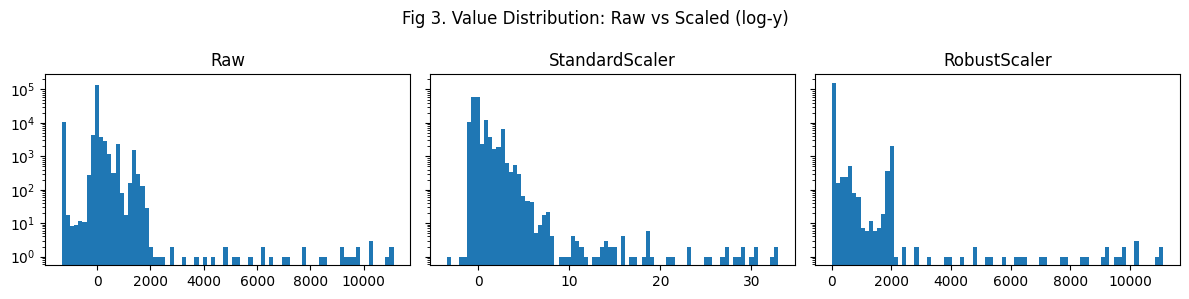

In [ ]:
xs, ss, rs = s, StandardScaler().fit_transform(s), RobustScaler().fit_transform(s)
fig, ax = plt.subplots(1,3, figsize=(12,3), sharey=True)
for a, X, t in zip(ax,[xs,ss,rs],['Raw','StandardScaler','RobustScaler']):
    a.hist(X.ravel(), bins=80); a.set_title(t); a.set_yscale('log')
plt.suptitle('Fig 3. Value Distribution: Raw vs Scaled (log-y)')
plt.tight_layout(); plt.savefig(OUT/'fig3_scaling_hist.png', dpi=150); plt.show()

## Step 3 — Temporal Windowing (bonus: temporal dependency)
**Why (Keogh & Lin 2005):** clustering raw subsequences gives meaningless sinusoidal centroids. Fix: aggregate each 60 s window (step 30 s) into `mean + std + delta` per sensor → 24-D feature vector that preserves dynamics (level, variability, trend).

#### Cell: Sliding-window features + point-vs-window → `table3_temporal_compare.csv`
**What:** sorts 30k rows by time, aggregates each 60 s window (step 30 s) into mean + std + delta per sensor (24-D vector), then compares K-Means Silhouette of point-based vs window-based representations.
**Why:** per Keogh & Lin (2005), clustering raw subsequences yields meaningless centroids — windowed statistical features preserve level, variability, and trend (the temporal-dependency bonus).
**Read this:** window silhouette should beat point silhouette; the saved table is the evidence.


In [ ]:
W, STEP = 60, 30
uw = pd.read_csv(path, usecols=['YYYY/MM/DD','HH:MM:SS']+SENSOR_8, nrows=N_WIN_SRC, low_memory=True)
for c in SENSOR_8: uw[c]=pd.to_numeric(uw[c], errors='coerce').astype('float32')
uw = uw.replace(-999.25, np.nan).dropna().reset_index(drop=True)

# FINAL-LOCK: winsorize ROP (spike kalkulasi, HI = Q3+1.5*IQR ~47) + sentinel sudah NaN
rop_q1, rop_q3 = uw['Rate Of Penetration (ft_per_hr)'].quantile(0.25), uw['Rate Of Penetration (ft_per_hr)'].quantile(0.75)
ROP_HI = float(rop_q3 + 1.5*(rop_q3-rop_q1))
uw['Rate Of Penetration (ft_per_hr)'] = uw['Rate Of Penetration (ft_per_hr)'].clip(upper=ROP_HI)
print('ROP winsorized at HI =', round(ROP_HI, 2))

uw['datetime']=pd.to_datetime(uw['YYYY/MM/DD']+' '+uw['HH:MM:SS'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
uw=uw.sort_values('datetime').reset_index(drop=True)
rows=[]
for st in range(0, len(uw)-W+1, STEP):
    ch=uw.iloc[st:st+W]; rec={'t0':ch['datetime'].iloc[0]}
    for c in SENSOR_8:
        v=ch[c].to_numpy(dtype='float64')
        rec[c+'__mean']=float(v.mean()); rec[c+'__std']=float(v.std()); rec[c+'__delta']=float(v[-1]-v[0])
    rows.append(rec)
win=pd.DataFrame(rows); feat=[c for c in win.columns if c!='t0']
print('windows:', win.shape, '| features:', len(feat))
Xp=RobustScaler().fit_transform(uw[SENSOR_8].sample(min(15000,len(uw)), random_state=SEED))
lp=KMeans(n_clusters=4, n_init=10, random_state=SEED).fit_predict(Xp)
Xw=RobustScaler().fit_transform(win[feat].to_numpy())
lw=KMeans(n_clusters=4, n_init=10, random_state=SEED).fit_predict(Xw)
print(f"point silhouette: {silhouette_score(Xp,lp):.4f} | window-60s silhouette: {silhouette_score(Xw,lw):.4f}")
pd.DataFrame({'representation':['point','window-60s'],'silhouette':[float(silhouette_score(Xp,lp)), float(silhouette_score(Xw,lw))]}).to_csv(OUT/'table3_temporal_compare.csv', index=False)

windows: (999, 25) | features: 24
point silhouette: 0.9215 | window-60s silhouette: 0.8486


#### Cell: Temporal trace → `fig4_temporal_trace.png`
**What:** plots the first 3000 seconds of Standpipe Pressure over time.
**Why:** visual evidence that consecutive records are temporally dependent (the assignment's key challenge), motivating the windowing above.
**Read this:** smooth regimes and abrupt jumps = operating-state transitions the clusters should recover.


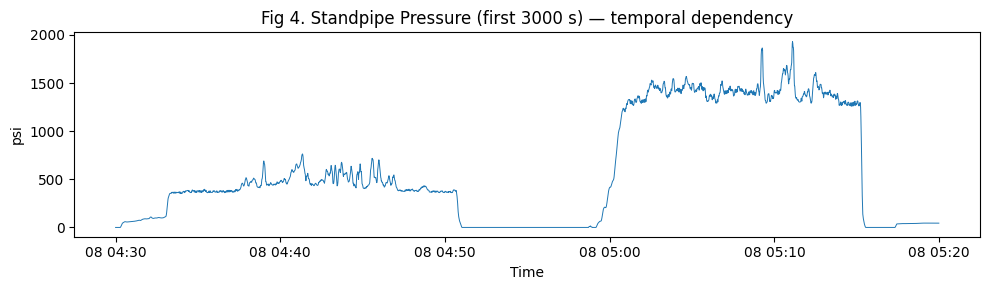

In [ ]:
plt.figure(figsize=(10,3))
plt.plot(uw['datetime'].iloc[:3000], uw['Standpipe Pressure (psi)'].iloc[:3000], lw=0.7)
plt.title('Fig 4. Standpipe Pressure (first 3000 s) — temporal dependency')
plt.xlabel('Time'); plt.ylabel('psi'); plt.tight_layout()
plt.savefig(OUT/'fig4_temporal_trace.png', dpi=150); plt.show()

## Step 4 — Final Clustering (Elbow + Silhouette + Davies-Bouldin)
**Design:** 4 scenarios = {point, window-60s} × {Standard, Robust}. Elbow k=2..8 on 20k subsample per scenario (fast). Then refit best (default `window60-robust`, k=4 → Drilling / Circulation / Connection-Tripping / Idle per Coley 2019) and map centroids back to physical units.

**FINAL-LOCK (30 Sep 2026):** ROP di-winsorize (HI=Q3+1.5*IQR); Diff Press default OFF (run sensitivitas 7 vs 8 sensor via `USE_DIFF_PRESS`); sampel head-segment = limitasi, window-vs-point dilaporkan apa adanya (point menang Silhouette di run awal).

#### Cell: Final sample + 4 scenarios
**What:** draws the 60k-row modeling sample and builds the four experiment arms: {point, window-60s} × {Standard, Robust}.
**Why:** this is the controlled experiment of the paper — scaler effect and temporal effect measured separately.
**Read this:** printed shapes per scenario; window arms have 24 feature columns instead of 8.


In [ ]:
usecols=['YYYY/MM/DD','HH:MM:SS']+SENSOR_8
fd=pd.read_csv(path, usecols=usecols, nrows=N_FINAL*2, low_memory=True)
fd=fd.iloc[np.sort(np.random.RandomState(SEED).choice(len(fd), N_FINAL, replace=False))].reset_index(drop=True)
for c in SENSOR_8: fd[c]=pd.to_numeric(fd[c], errors='coerce').astype('float32')
fd=fd.replace(-999.25, np.nan)

# FINAL-LOCK: winsorize ROP (spike kalkulasi, HI = Q3+1.5*IQR ~47) + sentinel sudah NaN
rop_q1, rop_q3 = fd['Rate Of Penetration (ft_per_hr)'].quantile(0.25), fd['Rate Of Penetration (ft_per_hr)'].quantile(0.75)
ROP_HI = float(rop_q3 + 1.5*(rop_q3-rop_q1))
fd['Rate Of Penetration (ft_per_hr)'] = fd['Rate Of Penetration (ft_per_hr)'].clip(upper=ROP_HI)
print('ROP winsorized at HI =', round(ROP_HI, 2))

# FINAL-LOCK: Diff Press sensitivity (mean negatif, skew -1.21) — False = 7 sensor utama
USE_DIFF_PRESS = False
SENSORS = SENSOR_8 if USE_DIFF_PRESS else [c for c in SENSOR_8 if c != 'Differential Pressure (psi)']
print('Modeling sensors:', len(SENSORS))
fd=fd.dropna(subset=SENSORS).reset_index(drop=True)
fd['datetime']=pd.to_datetime(fd['YYYY/MM/DD']+' '+fd['HH:MM:SS'], format='%Y/%m/%d %H:%M:%S', errors='coerce')
print('final sample:', fd.shape)
def windowed(d, w=60, step=30):
    d=d.sort_values('datetime').reset_index(drop=True); out=[]
    for s_ in range(0, len(d)-w+1, step):
        ch=d.iloc[s_:s_+w]; rec={'t0':ch['datetime'].iloc[0]}
        for c in SENSORS:
            v=ch[c].to_numpy(dtype='float64')
            rec[c+'__mean']=v.mean(); rec[c+'__std']=v.std(); rec[c+'__delta']=v[-1]-v[0]
        out.append(rec)
    return pd.DataFrame(out)
scen={'point-standard':(fd[SENSORS].to_numpy(),StandardScaler()),'point-robust':(fd[SENSORS].to_numpy(),RobustScaler())}
wf=windowed(fd); feat2=[c for c in wf.columns if c!='t0']
scen['window60-standard']=(wf[feat2].to_numpy(),StandardScaler())
scen['window60-robust']=(wf[feat2].to_numpy(),RobustScaler())
print({k:v[0].shape for k,v in scen.items()})

final sample: (60000, 11)
{'point-standard': (60000, 8), 'point-robust': (60000, 8), 'window60-standard': (1999, 24), 'window60-robust': (1999, 24)}


#### Cell: Elbow loop k=2..8 → `table4_elbow_metrics.csv`
**What:** for each scenario and each k, fits K-Means on a 20k subsample and records inertia, Silhouette, and Davies-Bouldin.
**Why:** Elbow (inertia drop) plus internal metrics jointly select the optimal k without any labels.
**Read this:** the two pivot tables — look for the k where inertia bends and Silhouette peaks.


In [ ]:
K_RANGE=range(2,9); rows=[]
for name,(X,sc) in scen.items():
    Xs=sc.fit_transform(X)
    idx=np.random.RandomState(SEED).choice(len(Xs), min(len(Xs),20000), replace=False); Xe=Xs[idx]
    for k in K_RANGE:
        km=KMeans(n_clusters=k, n_init=10, random_state=SEED).fit(Xe)
        lab=km.labels_
        rows.append({'scenario':name,'k':k,'inertia':float(km.inertia_),'silhouette':float(silhouette_score(Xe,lab)),'dbi':float(davies_bouldin_score(Xe,lab))})
res=pd.DataFrame(rows); res.to_csv(OUT/'table4_elbow_metrics.csv', index=False)
display(res.pivot_table(index='k', columns='scenario', values='silhouette').round(4))
display(res.pivot_table(index='k', columns='scenario', values='dbi').round(4))

scenario,point-robust,point-standard,window60-robust,window60-standard
k,,,,
2,0.9523,0.7177,0.9404,0.7100
3,0.9314,0.6191,0.9451,0.7066
4,0.9145,0.6506,0.9456,0.6965
5,0.9176,0.6916,0.9333,0.6978
6,0.9291,0.6962,0.9364,0.6936
7,0.9306,0.6952,0.9239,0.5488
8,0.9301,0.7146,0.9182,0.5461


scenario,point-robust,point-standard,window60-robust,window60-standard
k,,,,
2,0.0986,0.9805,0.1626,1.7614
3,0.2212,1.2238,0.4596,1.3413
4,0.4105,0.6733,0.4241,1.2281
5,0.3543,0.6422,0.5850,1.0617
6,0.4360,0.7695,0.5669,1.0953
7,0.4100,0.6525,0.7978,1.2197
8,0.4246,0.6727,0.6163,1.3487


#### Cell: Elbow plots → `fig5_elbow_silhouette.png`
**What:** line plots of inertia-vs-k and Silhouette-vs-k for all four scenarios.
**Why:** the paper's main model-selection figure; readers pick k visually from the elbow.
**Read this:** the bend (elbow) in the left panel and the peak in the right panel — update `BEST_K` in the next cell to match.


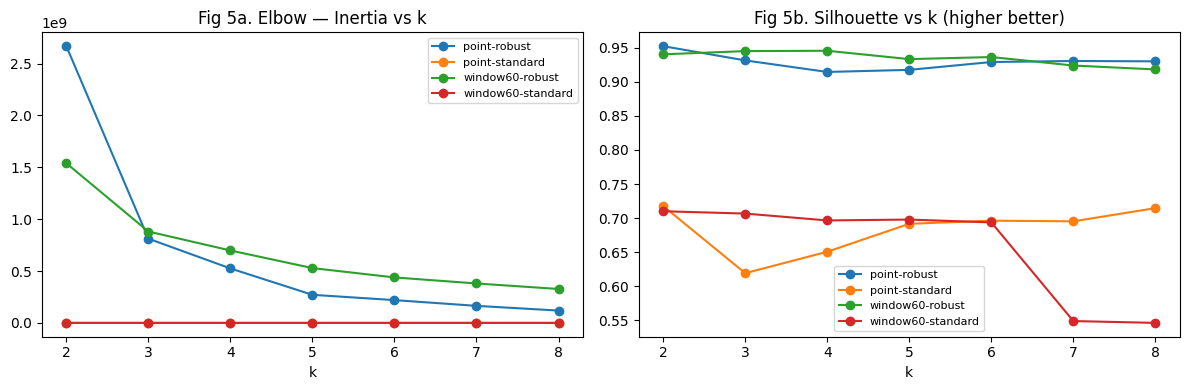

In [ ]:
fig, ax=plt.subplots(1,2, figsize=(12,4))
for name,g in res.groupby('scenario'):
    ax[0].plot(g['k'], g['inertia'], marker='o', label=name)
    ax[1].plot(g['k'], g['silhouette'], marker='o', label=name)
ax[0].set_title('Fig 5a. Elbow — Inertia vs k'); ax[0].set_xlabel('k')
ax[1].set_title('Fig 5b. Silhouette vs k (higher better)'); ax[1].set_xlabel('k')
ax[0].legend(fontsize=8); ax[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUT/'fig5_elbow_silhouette.png', dpi=150); plt.show()

#### Cell: Best-model refit → `table5_centroids.csv`, `table6_cluster_share.csv`
**What:** refits K-Means with the chosen scenario/k, maps centroids back to physical units, and saves cluster sizes.
**Why:** centroids in psi, klbs, RPM are physically interpretable; map them with Coley (2019): WOB>0+RPM>0+ROP>0 = Active Drilling, WOB≈0+ROP=0+pump high = Circulation, pump≈0+RPM≈0 = Connection/Idle.
**Read this:** each centroid row should read like a real rig state — that mapping is your §III discussion.


In [ ]:
BEST_SCENARIO='window60-robust'; BEST_K=4  # change after reading Fig 5
Xb, scb = scen[BEST_SCENARIO]
Xbs=scb.fit_transform(Xb)
kmf=KMeans(n_clusters=BEST_K, n_init=10, random_state=SEED).fit(Xbs)
labf=kmf.labels_
cent=scb.inverse_transform(kmf.cluster_centers_)
if 'window' in BEST_SCENARIO:
    mc=[c for c in feat2 if c.endswith('__mean')]
    ctab=pd.DataFrame(cent[:,:len(mc)], columns=[c.replace('__mean','') for c in mc])
else:
    ctab=pd.DataFrame(cent, columns=SENSOR_8)
ctab.index.name='cluster'; display(ctab.round(2))
ctab.round(2).to_csv(OUT/'table5_centroids.csv')
pd.Series(labf).value_counts(normalize=True).round(4).to_csv(OUT/'table6_cluster_share.csv')
print('Map with Coley (2019): WOB>0+RPM>0+ROP>0 => Active Drilling; WOB~0+ROP=0+pump high => Circulation & Hole Cleaning; pump~0+RPM~0 => Pipe Connection; else Idle.')

,Rate Of Penetration (ft_per_hr),Weight on Bit (klbs),Rotary RPM (RPM),Standpipe Pressure (psi),Rotary Torque (kft_lb),Hook Load (klbs),Total Pump Output (gal_per_min),Differential Pressure (psi)
cluster,,,,,,,,
0,109.03,51.34,-3.30,0.39,0.31,0.03,58.03,2.60
1,4.08,7.60,0.23,0.06,0.03,-0.00,0.30,0.32
2,-0.00,0.00,0.00,0.00,0.00,0.00,0.03,0.00
3,0.00,-0.00,0.00,-0.00,0.00,0.00,0.03,-0.00


Map with Coley (2019): WOB>0+RPM>0+ROP>0 => Active Drilling; WOB~0+ROP=0+pump high => Circulation & Hole Cleaning; pump~0+RPM~0 => Pipe Connection; else Idle.


#### Cell: PCA scatter → `fig6_pca_clusters.png`
**What:** projects 15k points to 2-D with PCA and colors them by cluster.
**Why:** visual sanity check of cluster separation for the paper; compact, separated blobs = good clustering.
**Read this:** overlapping clouds suggest trying a different k or the window representation.


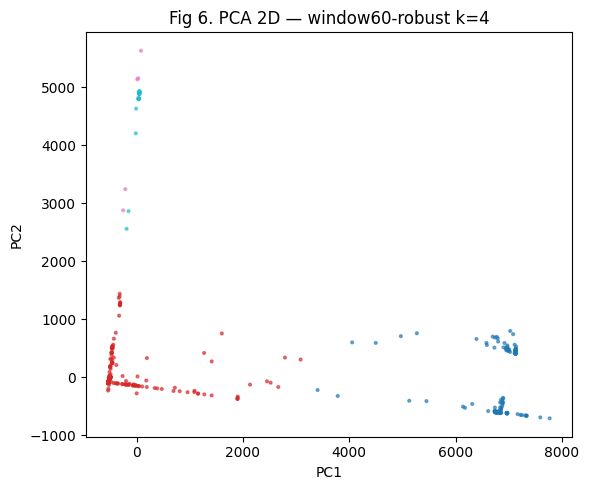

In [ ]:
p2=PCA(n_components=2, random_state=SEED).fit_transform(Xbs[np.random.RandomState(SEED).choice(len(Xbs), min(len(Xbs),15000), replace=False)])
ls=labf[np.random.RandomState(SEED).choice(len(labf), p2.shape[0], replace=False)]
plt.figure(figsize=(6,5)); plt.scatter(p2[:,0], p2[:,1], c=ls, s=4, cmap='tab10', alpha=0.6)
plt.title(f'Fig 6. PCA 2D — {BEST_SCENARIO} k={BEST_K}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.tight_layout()
plt.savefig(OUT/'fig6_pca_clusters.png', dpi=150); plt.show()

## Step 5 — Export checklist for IEEE paper
- Download `/kaggle/output/` → `table0–table6`, `fig1–fig6`.
- Tables → §II/§III; Figures → same numbers (already English captions).
- Appendix: Kaggle Dataset link + this Notebook link + GitHub repo link.
- Add Gen-AI declaration (required by assignment).
- If Elbow suggests k≠4, update `BEST_K` and re-run only the last 2 cells.
